### Modelos

In [1]:
#Librerias
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import sqrt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential, load_model
from keras.layers import Dense, LSTM, Dropout, Input
from sklearn.metrics import mean_squared_error as mse
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


In [2]:
data = pd.read_csv('/content/data_clean.csv')
data.head()

,date,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
0,2010-01-02 00:00:00,129.0,-16,-4.0,1020.0,2,1.79,0,0
1,2010-01-02 01:00:00,148.0,-15,-4.0,1020.0,2,2.68,0,0
2,2010-01-02 02:00:00,159.0,-11,-5.0,1021.0,2,3.57,0,0
3,2010-01-02 03:00:00,181.0,-7,-5.0,1022.0,2,5.36,1,0
4,2010-01-02 04:00:00,138.0,-7,-5.0,1022.0,2,6.25,2,0


In [70]:
# Variable objetivo
y = data['pm2.5']

# Variables predictoras /Caracteristicas
X = data[['pm2.5','DEWP', 'TEMP', 'PRES', 'cbwd', 'Iws', 'Is', 'Ir']]

n = len(data)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

# Datos de entrenamiento
X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

# Datos de validación
X_val = X.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]

# Datos de prueba / inferencia
X_test = X.iloc[val_end:]
y_test = y.iloc[val_end:]

#Escalar las caracteristicas / Features
scaler_X = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

#Escalar la salida / variable objetivo
scaler_y = MinMaxScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_val_scaled = scaler_y.transform(y_val.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (29229, 8)
y_train: (29229,)
X_val: (6264, 8)
y_val: (6264,)
X_test: (6264, 8)
y_test: (6264,)


In [180]:
#Creando secuencia para el modelo LSTM

#Paso del tiempo -> 24h antes para el entrenamiento
time_steps = 24


def create_sequences(X, y, time_steps):
    X_seq = []
    y_seq = []

    for i in range(time_steps, len(X)):
        X_seq.append(X[i-time_steps:i])
        y_seq.append(y[i])

    return np.array(X_seq), np.array(y_seq)

#Creando secuencia para cada conjunto de datos
X_train_seq, y_train_seq = create_sequences(
    X_train_scaled,
    y_train_scaled,
    time_steps
)

X_val_seq, y_val_seq = create_sequences(
    X_val_scaled,
    y_val_scaled,
    time_steps
)

X_test_seq, y_test_seq = create_sequences(
    X_test_scaled,
    y_test_scaled,
    time_steps
)

print("X_train_seq:", X_train_seq.shape)
print("y_train_seq:", y_train_seq.shape)
print("X_val_seq:", X_test_seq.shape)
print("y_val_seq:", y_test_seq.shape)
print("X_test_seq:", X_test_seq.shape)
print("y_test_seq:", y_test_seq.shape)

X_train_seq: (29205, 24, 8)
y_train_seq: (29205, 1)
X_val_seq: (6240, 24, 8)
y_val_seq: (6240, 1)
X_test_seq: (6240, 24, 8)
y_test_seq: (6240, 1)


In [181]:
# Creating a sequential model
model = Sequential()

#Capa inicial: Estructura de la muestra que depende de la ventana que se esta usando ->time_steps
model.add(Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2])))

# Primera capa con 16 unidades. Devuelve información para cada time_steps
model.add(LSTM(units=16, return_sequences=False)) #Salida -> (time_steps,units)

#model.add(LSTM(units=32, return_sequences=False))

#Regulariza el overfittinf ((sobre-entrenamiento)). Durante el entrenamiento desactiva el 20% de las activaciones aleatoriamente
#model.add(Dropout(0.2))

# Capa de salida. Predecir un unico valor para pm2.5
model.add(Dense(units=1))

# Compilando modelo usando optimizador Adam que ayuda ajustar los pesos de la red neuronal
model.compile(optimizer=Adam(learning_rate=0.001), metrics=[RootMeanSquaredError()], loss='mse')

#early_stopping: Configuracion que permite finalizar el entrenamiento del modelo antes de completar todas las épocas.
#Teniendo en cuenta si el conjunto de validacion deja de mejorar, para asi evitar el sobre-entrenamiento.
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

#Guarda el mejor modelo de acuerdo al entrenamiento.
Checkpoint = ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True)

model.summary()


Model: "sequential_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_36 (LSTM)                  │ (None, 16)             │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,617 (6.32 KB)

 Trainable params: 1,617 (6.32 KB)

 Non-trainable params: 0 (0.00 B)

In [182]:
#Entrenamiento modelo y validacion de dato
history = model.fit(X_train_seq, y_train_seq, epochs=100, batch_size=32, validation_data=(X_val_seq, y_val_seq), callbacks=[early_stopping,Checkpoint], shuffle=False,verbose=1)


Epoch 1/100
913/913 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 0.0052 - root_mean_squared_error: 0.0723 - val_loss: 0.0038 - val_root_mean_squared_error: 0.0620
Epoch 2/100
913/913 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 0.0017 - root_mean_squared_error: 0.0413 - val_loss: 0.0016 - val_root_mean_squared_error: 0.0395
Epoch 3/100
913/913 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.0012 - root_mean_squared_error: 0.0344 - val_loss: 0.0012 - val_root_mean_squared_error: 0.0340
Epoch 4/100
913/913 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 9.4342e-04 - root_mean_squared_error: 0.0307 - val_loss: 0.0010 - val_root_mean_squared_error: 0.0318
Epoch 5/100
913/913 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 8.0503e-04 - root_mean_squared_error: 0.0284 - val_loss: 8.9767e-04 - val_root_mean_squared_error: 0.0300
Epoch 6/100
913/913 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 7.2433e-04 - root_mean_squared_error: 0.0269 - val_loss: 7.9424e-04 - val_root_mean_squared_error: 0.0282
Epoch 7/100
913/91

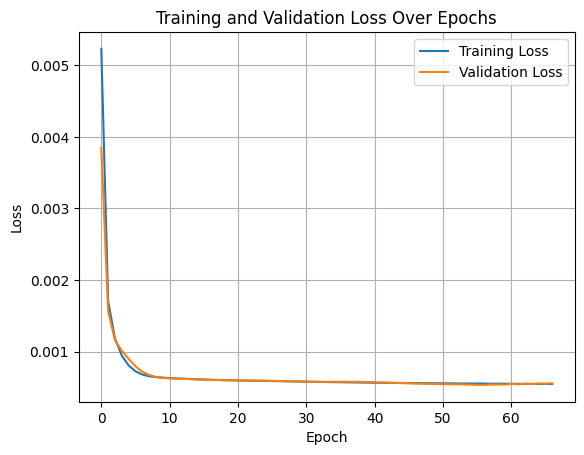

In [183]:
# Grafica perdida del error entrenamiento y validacion
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

#Labels
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss Over Epochs')
plt.grid()
plt.show()

195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


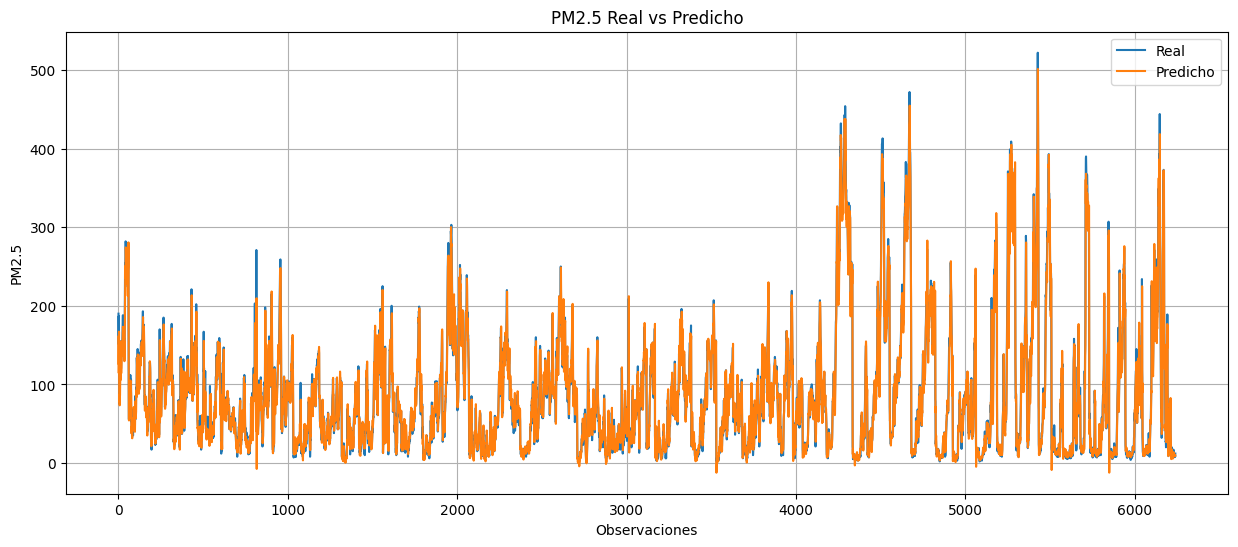

In [187]:
y_pred_scaled = model.predict(X_test_seq)

#Obtener valores originales de salida
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_real = scaler_y.inverse_transform(y_test_seq)

plt.figure(figsize=(15, 6))

plt.plot(y_real, label='Real')
plt.plot(y_pred, label='Predicho')

plt.title('PM2.5 Real vs Predicho')
plt.xlabel('Observaciones')
plt.ylabel('PM2.5')
#plt.xlim([4000,5000])
plt.legend()
plt.grid(True)

plt.show()

In [185]:
#Metricas
# Convertir a vectores
y_real = y_real.flatten()
y_pred = y_pred.flatten()

# Métricas
#Calcula el promedio de las diferencias absolutas entre los valores que predijo el modelo y los valores que pasaron de verdad en la realidad
mae = mean_absolute_error(y_real, y_pred)
mse = mean_squared_error(y_real, y_pred)
# Distancia típica entre los valores estimados y los reales.
rmse = np.sqrt(mse)
#Mide la variabilidad del modelo.
r2 = r2_score(y_real, y_pred)

print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

MAE:  10.5635
MSE:  312.0477
RMSE: 17.6649
R²:   0.9503


1. MAE: En promedio, el modelo se equivoca 10.5635 unidades de $PM_{2.5}$
2. RMSE: Error de predicción del modelo es de 17.66 $ug/m^{3}$
3. $R^2$: El modelo es capaz de explicar el 98% de la variabilidad de los datos.